# 第十二章：訊息傳遞神經網路 (MPNN)
## Neural Message Passing for Quantum Chemistry
### Justin Gilmer et al. (Google Brain, ICML 2017)

Message Passing Neural Networks 是圖神經網路的統一框架，將各種 GNN 方法統一為「訊息-聚合-更新」的範式。

**核心公式**：
$$m_v^{t+1} = \sum_{w \in N(v)} M_t(h_v^t, h_w^t, e_{vw})$$
$$h_v^{t+1} = U_t(h_v^t, m_v^{t+1})$$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 12.1 圖資料結構

首先定義如何在 PyTorch 中表示圖。

**關鍵組成**：
- `node_features`：節點特徵矩陣 [N, F]
- `edge_index`：COO 格式的邊連接 [2, E]
- `edge_features`：邊特徵矩陣 [E, D]（可選）

In [2]:
class GraphData:
    """簡單的圖資料結構"""
    
    def __init__(self, node_features, edge_index, edge_features=None):
        """
        Args:
            node_features: [N, F] 節點特徵矩陣
            edge_index: [2, E] 邊連接（來源, 目標）
            edge_features: [E, D] 邊特徵（可選）
        """
        self.x = node_features
        self.edge_index = edge_index
        self.edge_attr = edge_features
        
    @property
    def num_nodes(self):
        return self.x.shape[0]
    
    @property
    def num_edges(self):
        return self.edge_index.shape[1]
    
    def to(self, device):
        self.x = self.x.to(device)
        self.edge_index = self.edge_index.to(device)
        if self.edge_attr is not None:
            self.edge_attr = self.edge_attr.to(device)
        return self


def create_water_molecule():
    """建立 H2O 分子圖
    
    結構：
        H(1) -- O(0) -- H(2)
    """
    # 節點特徵：[原子序數, 價電子數] 正規化
    node_features = torch.tensor([
        [8/10, 2/4],   # 氧原子
        [1/10, 1/4],   # 氫原子
        [1/10, 1/4],   # 氫原子
    ], dtype=torch.float32)
    
    # 邊索引（無向圖，兩個方向都要）
    edge_index = torch.tensor([
        [0, 0, 1, 2],  # 來源
        [1, 2, 0, 0],  # 目標
    ], dtype=torch.long)
    
    # 邊特徵：[鍵類型 one-hot]
    edge_features = torch.tensor([
        [1, 0, 0],  # O-H 單鍵
        [1, 0, 0],  # O-H 單鍵
        [1, 0, 0],  # H-O 單鍵
        [1, 0, 0],  # H-O 單鍵
    ], dtype=torch.float32)
    
    return GraphData(node_features, edge_index, edge_features)


# 建立水分子
water = create_water_molecule()
print(f"水分子：")
print(f"  節點數：{water.num_nodes}")
print(f"  邊數：{water.num_edges}")
print(f"  節點特徵形狀：{water.x.shape}")
print(f"  邊索引形狀：{water.edge_index.shape}")

水分子：
  節點數：3
  邊數：4
  節點特徵形狀：torch.Size([3, 2])
  邊索引形狀：torch.Size([2, 4])


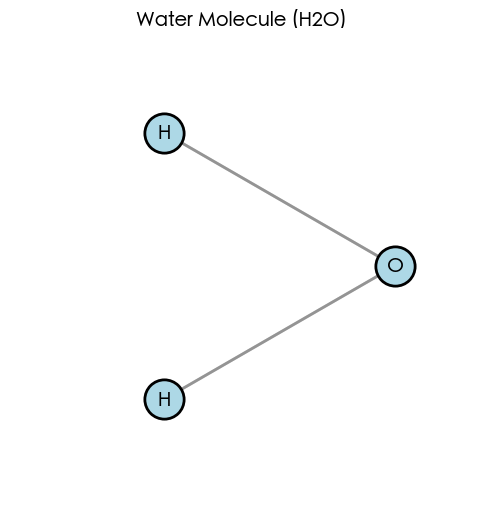

Saved: water_graph.png


In [3]:
def visualize_graph(graph, node_labels=None, title="Graph"):
    """視覺化圖結構"""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    n_nodes = graph.num_nodes
    
    # 將節點排列成圓形
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    pos = np.column_stack([np.cos(angles), np.sin(angles)])
    
    # 繪製邊
    edge_index = graph.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        src, tgt = edge_index[0, i], edge_index[1, i]
        ax.plot([pos[src, 0], pos[tgt, 0]], 
               [pos[src, 1], pos[tgt, 1]], 
               'gray', linewidth=2, alpha=0.6)
    
    # 繪製節點
    ax.scatter(pos[:, 0], pos[:, 1], s=800, c='lightblue', 
              edgecolors='black', linewidth=2, zorder=3)
    
    # 加入標籤
    if node_labels is None:
        node_labels = [str(i) for i in range(n_nodes)]
    for i, label in enumerate(node_labels):
        ax.annotate(label, pos[i], ha='center', va='center', 
                   fontsize=14, fontweight='bold')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return fig

# 視覺化水分子（標籤用英文避免亂碼）
fig = visualize_graph(water, ['O', 'H', 'H'], 'Water Molecule (H2O)')
plt.savefig('water_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: water_graph.png")

## 12.2 訊息傳遞層（NumPy 實作）

先用 NumPy 實作訊息傳遞，理解其運作機制。

In [4]:
def message_passing_numpy(node_features, edge_index, W_msg, W_update):
    """
    NumPy 實作的單步訊息傳遞
    
    Args:
        node_features: [N, feat_dim] 節點特徵
        edge_index: [2, E] 邊
        W_msg: [H, feat_dim] 訊息權重矩陣
        W_update: [feat_dim, feat_dim+H] 更新權重矩陣
    """
    N = node_features.shape[0]
    H = W_msg.shape[0]
    
    # 初始化聚合後的訊息
    aggregated = np.zeros((N, H))
    
    # 對每條邊，計算並聚合訊息
    for e in range(edge_index.shape[1]):
        src, tgt = edge_index[0, e], edge_index[1, e]
        
        # 訊息：轉換來源節點特徵
        message = np.tanh(W_msg @ node_features[src])
        
        # 聚合：加到目標節點
        aggregated[tgt] += message
    
    # 更新：結合節點特徵與聚合訊息
    new_features = np.zeros_like(node_features)
    for v in range(N):
        concat = np.concatenate([node_features[v], aggregated[v]])
        new_features[v] = np.tanh(W_update @ concat)
    
    return new_features


# 測試 NumPy 實作
node_feat = water.x.numpy()
edge_idx = water.edge_index.numpy()

feat_dim = node_feat.shape[1]  # 2
hidden_dim = 4

W_msg = np.random.randn(hidden_dim, feat_dim) * 0.1
W_update = np.random.randn(feat_dim, feat_dim + hidden_dim) * 0.1

print("初始節點特徵：")
print(node_feat)

new_feat = message_passing_numpy(node_feat, edge_idx, W_msg, W_update)
print("\n訊息傳遞後：")
print(new_feat)

初始節點特徵：
[[0.8  0.5 ]
 [0.1  0.25]
 [0.1  0.25]]

訊息傳遞後：
[[-0.02848505 -0.1703268 ]
 [-0.03053705 -0.0508769 ]
 [-0.03053705 -0.0508769 ]]


## 12.3 訊息傳遞層（PyTorch 實作）

現在實作帶有可學習參數的 PyTorch 版本。

In [5]:
class MessagePassingLayer(nn.Module):
    """基本訊息傳遞層"""
    
    def __init__(self, in_channels, out_channels, edge_dim=None):
        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # 訊息函數：MLP
        msg_input_dim = in_channels * 2  # 來源 + 目標
        if edge_dim is not None:
            msg_input_dim += edge_dim
        
        self.message_mlp = nn.Sequential(
            nn.Linear(msg_input_dim, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )
        
        # 更新函數：類似 GRU
        self.update_mlp = nn.Sequential(
            nn.Linear(in_channels + out_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )
        
    def forward(self, x, edge_index, edge_attr=None):
        """
        Args:
            x: [N, in_channels] 節點特徵
            edge_index: [2, E] 邊連接
            edge_attr: [E, edge_dim] 邊特徵（可選）
        
        Returns:
            [N, out_channels] 更新後的節點特徵
        """
        N = x.shape[0]
        
        # 取得每條邊的來源和目標節點特徵
        src_idx = edge_index[0]  # [E]
        tgt_idx = edge_index[1]  # [E]
        
        src_features = x[src_idx]  # [E, in_channels]
        tgt_features = x[tgt_idx]  # [E, in_channels]
        
        # 計算訊息
        if edge_attr is not None:
            msg_input = torch.cat([src_features, tgt_features, edge_attr], dim=1)
        else:
            msg_input = torch.cat([src_features, tgt_features], dim=1)
        
        messages = self.message_mlp(msg_input)  # [E, out_channels]
        
        # 聚合訊息（scatter add）
        aggregated = torch.zeros(N, self.out_channels, device=x.device)
        aggregated.scatter_add_(0, tgt_idx.unsqueeze(1).expand(-1, self.out_channels), messages)
        
        # 更新節點特徵
        update_input = torch.cat([x, aggregated], dim=1)
        x_new = self.update_mlp(update_input)
        
        return x_new


# 測試
mp_layer = MessagePassingLayer(in_channels=2, out_channels=8, edge_dim=3)
water_gpu = water.to(device)

out = mp_layer(water_gpu.x, water_gpu.edge_index, water_gpu.edge_attr)
print(f"輸入形狀：{water_gpu.x.shape}")
print(f"輸出形狀：{out.shape}")
print(f"\n層參數量：{sum(p.numel() for p in mp_layer.parameters()):,}")

輸入形狀：torch.Size([3, 2])
輸出形狀：torch.Size([3, 8])

層參數量：296


## 12.4 完整 MPNN 模型

In [6]:
class MPNN(nn.Module):
    """訊息傳遞神經網路"""
    
    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers, output_dim):
        super().__init__()
        
        self.num_layers = num_layers
        
        # 節點嵌入
        self.node_embed = nn.Linear(node_dim, hidden_dim)
        
        # 訊息傳遞層
        self.mp_layers = nn.ModuleList([
            MessagePassingLayer(hidden_dim, hidden_dim, edge_dim)
            for _ in range(num_layers)
        ])
        
        # 讀出層（圖級別預測）
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, graph):
        """
        Args:
            graph: GraphData 物件
        
        Returns:
            圖級別預測
        """
        x = graph.x
        edge_index = graph.edge_index
        edge_attr = graph.edge_attr
        
        # 嵌入節點特徵
        x = F.relu(self.node_embed(x))
        
        # 訊息傳遞
        for mp_layer in self.mp_layers:
            x = F.relu(mp_layer(x, edge_index, edge_attr))
        
        # 讀出：求和池化
        graph_repr = x.sum(dim=0, keepdim=True)  # [1, hidden_dim]
        
        # 預測
        output = self.readout(graph_repr)
        
        return output


# 建立 MPNN
mpnn = MPNN(
    node_dim=2,
    edge_dim=3,
    hidden_dim=32,
    num_layers=3,
    output_dim=1
).to(device)

# 前向傳播
pred = mpnn(water_gpu)
print(f"圖級別預測：{pred.item():.4f}")
print(f"總參數量：{sum(p.numel() for p in mpnn.parameters()):,}")

圖級別預測：-0.0318
總參數量：20,289


## 12.5 視覺化訊息傳遞過程

/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_18925/3714241067.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


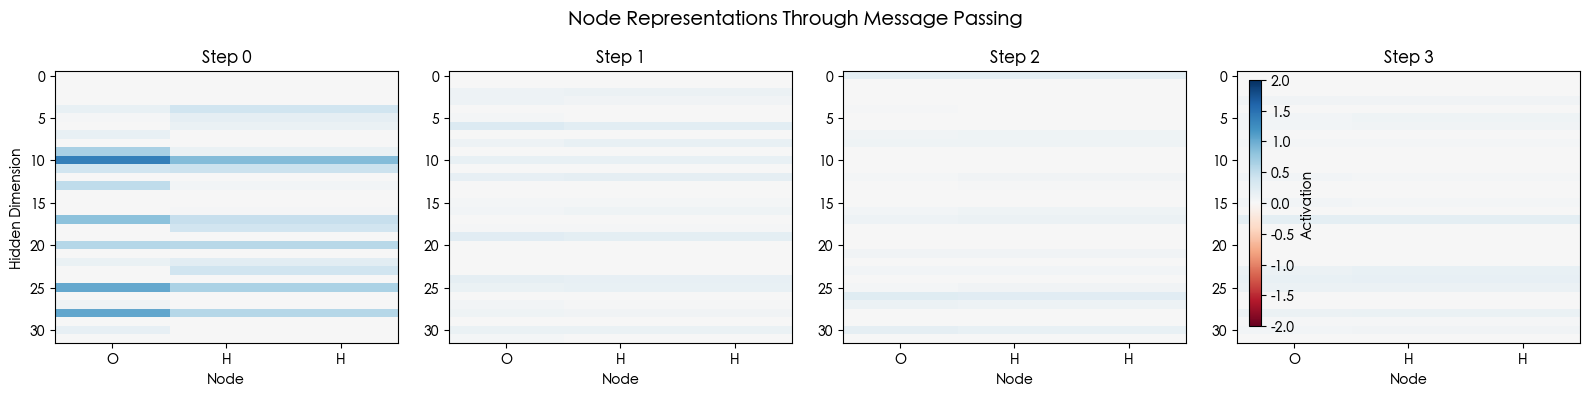

Saved: message_passing_evolution.png


In [7]:
def visualize_message_passing(model, graph, node_labels):
    """視覺化節點表示如何在訊息傳遞中演化"""
    
    model.eval()
    
    # 收集中間表示
    representations = []
    
    with torch.no_grad():
        x = graph.x
        edge_index = graph.edge_index
        edge_attr = graph.edge_attr
        
        # 初始嵌入
        x = F.relu(model.node_embed(x))
        representations.append(x.cpu().numpy())
        
        # 經過每個 MP 層
        for mp_layer in model.mp_layers:
            x = F.relu(mp_layer(x, edge_index, edge_attr))
            representations.append(x.cpu().numpy())
    
    # 繪圖（標籤用英文避免亂碼）
    n_steps = len(representations)
    fig, axes = plt.subplots(1, n_steps, figsize=(4*n_steps, 4))
    
    for step, rep in enumerate(representations):
        ax = axes[step]
        im = ax.imshow(rep.T, cmap='RdBu', aspect='auto', vmin=-2, vmax=2)
        
        ax.set_title(f'Step {step}', fontsize=12)
        ax.set_xlabel('Node')
        if step == 0:
            ax.set_ylabel('Hidden Dimension')
        ax.set_xticks(range(len(node_labels)))
        ax.set_xticklabels(node_labels)
    
    plt.colorbar(im, ax=axes, label='Activation', shrink=0.8)
    plt.suptitle('Node Representations Through Message Passing', fontsize=14)
    plt.tight_layout()
    plt.savefig('message_passing_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: message_passing_evolution.png")

visualize_message_passing(mpnn, water_gpu, ['O', 'H', 'H'])

## 12.6 不同聚合函數

聚合方式比較：
Sum: torch.Size([3, 8])
Mean: torch.Size([3, 8])
Max: torch.Size([3, 8])


/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_18925/4069381388.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


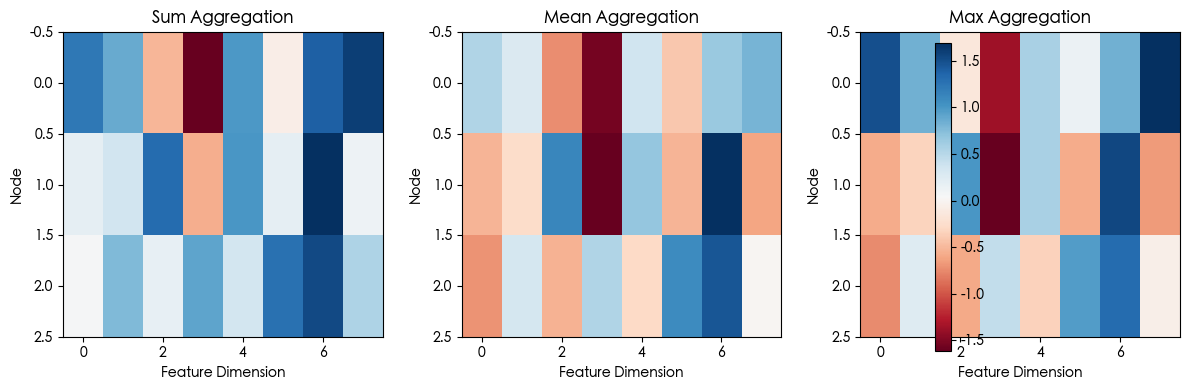

Saved: aggregation_comparison.png


In [8]:
def aggregate_sum(messages, target_idx, num_nodes):
    """求和聚合"""
    out = torch.zeros(num_nodes, messages.shape[1], device=messages.device)
    out.scatter_add_(0, target_idx.unsqueeze(1).expand_as(messages), messages)
    return out

def aggregate_mean(messages, target_idx, num_nodes):
    """平均聚合"""
    out = aggregate_sum(messages, target_idx, num_nodes)
    count = torch.zeros(num_nodes, 1, device=messages.device)
    count.scatter_add_(0, target_idx.unsqueeze(1), torch.ones_like(target_idx.unsqueeze(1), dtype=torch.float))
    count = count.clamp(min=1)  # 避免除以零
    return out / count

def aggregate_max(messages, target_idx, num_nodes):
    """最大值聚合"""
    out = torch.full((num_nodes, messages.shape[1]), float('-inf'), device=messages.device)
    out.scatter_reduce_(0, target_idx.unsqueeze(1).expand_as(messages), messages, reduce='amax')
    out[out == float('-inf')] = 0
    return out


# 比較不同聚合方式
messages = torch.randn(4, 8)  # 4 個訊息，8 維特徵
target_idx = torch.tensor([0, 0, 1, 2])  # 訊息傳給節點 0, 0, 1, 2
num_nodes = 3

print("聚合方式比較：")
print(f"Sum: {aggregate_sum(messages, target_idx, num_nodes).shape}")
print(f"Mean: {aggregate_mean(messages, target_idx, num_nodes).shape}")
print(f"Max: {aggregate_max(messages, target_idx, num_nodes).shape}")

# 視覺化（標籤用英文避免亂碼）
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

agg_results = [
    ('Sum', aggregate_sum(messages, target_idx, num_nodes)),
    ('Mean', aggregate_mean(messages, target_idx, num_nodes)),
    ('Max', aggregate_max(messages, target_idx, num_nodes))
]

for ax, (name, result) in zip(axes, agg_results):
    im = ax.imshow(result.numpy(), cmap='RdBu', aspect='auto')
    ax.set_title(f'{name} Aggregation', fontsize=12)
    ax.set_xlabel('Feature Dimension')
    ax.set_ylabel('Node')

plt.colorbar(im, ax=axes)
plt.tight_layout()
plt.savefig('aggregation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: aggregation_comparison.png")

## 12.7 圖卷積網路（GCN）

GCN 是 MPNN 的一個特例，使用簡化的訊息傳遞：
$$H^{(l+1)} = \sigma(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)})$$

In [9]:
class GCNLayer(nn.Module):
    """圖卷積層"""
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channels))
        
    def forward(self, x, edge_index):
        """
        Args:
            x: [N, in_channels] 節點特徵
            edge_index: [2, E] 邊
        """
        N = x.shape[0]
        
        # 加入自環
        self_loop_idx = torch.arange(N, device=x.device)
        edge_index = torch.cat([
            edge_index,
            torch.stack([self_loop_idx, self_loop_idx])
        ], dim=1)
        
        # 計算度數
        src_idx = edge_index[0]
        tgt_idx = edge_index[1]
        
        degree = torch.zeros(N, device=x.device)
        degree.scatter_add_(0, tgt_idx, torch.ones(edge_index.shape[1], device=x.device))
        
        # 對稱正規化：D^{-1/2} A D^{-1/2}
        deg_inv_sqrt = degree.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        
        norm = deg_inv_sqrt[src_idx] * deg_inv_sqrt[tgt_idx]
        
        # 轉換特徵
        x = self.linear(x)
        
        # 帶正規化的訊息傳遞
        out = torch.zeros_like(x)
        messages = x[src_idx] * norm.unsqueeze(1)
        out.scatter_add_(0, tgt_idx.unsqueeze(1).expand_as(messages), messages)
        
        return out + self.bias


class GCN(nn.Module):
    """圖卷積網路"""
    
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        
        self.layers = nn.ModuleList()
        
        # 第一層
        self.layers.append(GCNLayer(in_channels, hidden_channels))
        
        # 隱藏層
        for _ in range(num_layers - 2):
            self.layers.append(GCNLayer(hidden_channels, hidden_channels))
        
        # 輸出層
        self.layers.append(GCNLayer(hidden_channels, out_channels))
        
    def forward(self, x, edge_index):
        for i, layer in enumerate(self.layers[:-1]):
            x = F.relu(layer(x, edge_index))
        x = self.layers[-1](x, edge_index)
        return x


# 測試 GCN
gcn = GCN(in_channels=2, hidden_channels=16, out_channels=8, num_layers=3).to(device)
out = gcn(water_gpu.x, water_gpu.edge_index)

print(f"GCN 輸出形狀：{out.shape}")
print(f"GCN 參數量：{sum(p.numel() for p in gcn.parameters()):,}")

GCN 輸出形狀：torch.Size([3, 8])
GCN 參數量：456


## 12.8 建立更大的圖（苯分子）

苯分子：
  節點數：12（6 C + 6 H）
  邊數：24


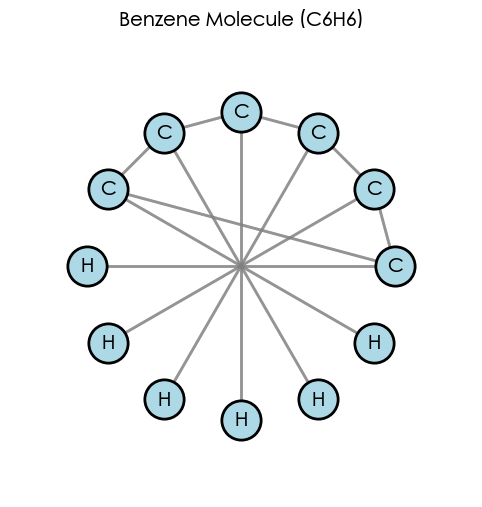

Saved: benzene_graph.png


In [10]:
def create_benzene():
    """建立苯分子 (C6H6) 圖
    
    結構：6 個碳原子組成的六角環，每個碳連接 1 個氫
    """
    # 6 個碳 (0-5) + 6 個氫 (6-11)
    node_features = []
    
    # 碳原子
    for _ in range(6):
        node_features.append([6/10, 4/4])  # 原子序數=6, 價電子=4
    
    # 氫原子
    for _ in range(6):
        node_features.append([1/10, 1/4])  # 原子序數=1, 價電子=1
    
    node_features = torch.tensor(node_features, dtype=torch.float32)
    
    # 邊
    edges = []
    
    # 碳環（芳香鍵）
    for i in range(6):
        j = (i + 1) % 6
        edges.append([i, j])
        edges.append([j, i])  # 無向
    
    # C-H 鍵
    for i in range(6):
        h_idx = 6 + i
        edges.append([i, h_idx])
        edges.append([h_idx, i])
    
    edge_index = torch.tensor(edges, dtype=torch.long).T
    
    # 邊特徵：[單鍵, 雙鍵, 芳香鍵]
    edge_features = []
    for e in range(edge_index.shape[1]):
        src = edge_index[0, e].item()
        tgt = edge_index[1, e].item()
        
        if src < 6 and tgt < 6:  # C-C 芳香鍵
            edge_features.append([0, 0, 1])
        else:  # C-H 單鍵
            edge_features.append([1, 0, 0])
    
    edge_features = torch.tensor(edge_features, dtype=torch.float32)
    
    return GraphData(node_features, edge_index, edge_features)


benzene = create_benzene()
print(f"苯分子：")
print(f"  節點數：{benzene.num_nodes}（6 C + 6 H）")
print(f"  邊數：{benzene.num_edges}")

# 視覺化（標籤用英文避免亂碼）
labels = ['C']*6 + ['H']*6
fig = visualize_graph(benzene, labels, 'Benzene Molecule (C6H6)')
plt.savefig('benzene_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: benzene_graph.png")

## 12.9 過度平滑視覺化

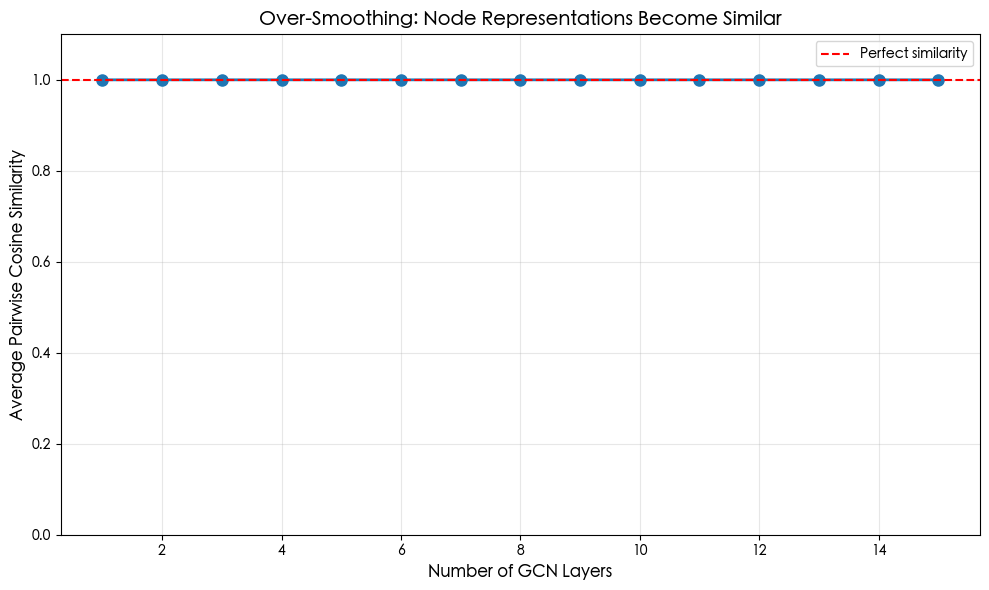

Saved: over_smoothing.png


In [11]:
def analyze_over_smoothing(graph, max_layers=10):
    """分析節點表示如何隨著層數增加而變得相似"""
    
    similarities = []
    
    for num_layers in range(1, max_layers + 1):
        # 建立不同深度的 GCN
        model = GCN(
            in_channels=2,
            hidden_channels=32,
            out_channels=32,
            num_layers=num_layers
        ).to(device)
        
        # 隨機初始化，不訓練
        model.eval()
        
        with torch.no_grad():
            out = model(graph.x, graph.edge_index)
            
            # 計算成對餘弦相似度
            out_norm = F.normalize(out, dim=1)
            sim_matrix = out_norm @ out_norm.T
            
            # 平均相似度（排除自身相似度）
            n = sim_matrix.shape[0]
            mask = ~torch.eye(n, dtype=torch.bool, device=device)
            avg_sim = sim_matrix[mask].mean().item()
            
            similarities.append(avg_sim)
    
    return similarities


# 在苯分子上分析
benzene_gpu = benzene.to(device)
similarities = analyze_over_smoothing(benzene_gpu, max_layers=15)

# 繪圖（標籤用英文避免亂碼）
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(similarities)+1), similarities, 'o-', linewidth=2, markersize=8)
ax.axhline(y=1.0, color='r', linestyle='--', label='Perfect similarity')
ax.set_xlabel('Number of GCN Layers', fontsize=12)
ax.set_ylabel('Average Pairwise Cosine Similarity', fontsize=12)
ax.set_title('Over-Smoothing: Node Representations Become Similar', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('over_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: over_smoothing.png")

## 12.10 感受野增長

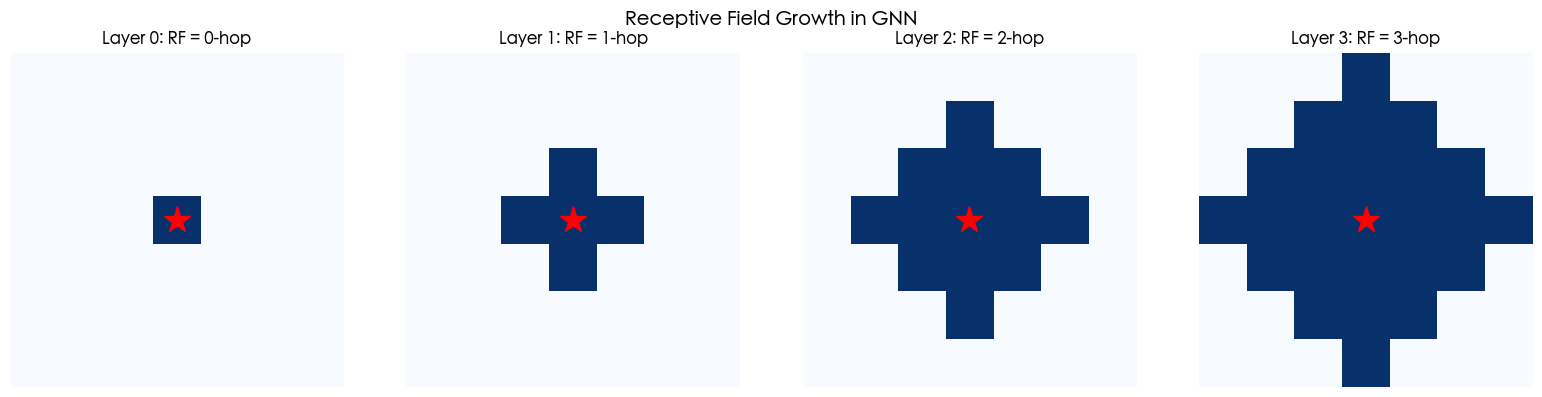

Saved: receptive_field_growth.png


In [12]:
def visualize_receptive_field():
    """視覺化感受野如何隨層數增長"""
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # 建立小型網格圖用於視覺化
    grid_size = 7
    center = grid_size // 2
    
    for layer, ax in enumerate(axes):
        grid = np.zeros((grid_size, grid_size))
        
        # 感受野是距離 <= layer 的所有節點
        for i in range(grid_size):
            for j in range(grid_size):
                dist = abs(i - center) + abs(j - center)  # 曼哈頓距離
                if dist <= layer:
                    grid[i, j] = 1
        
        ax.imshow(grid, cmap='Blues', vmin=0, vmax=1)
        ax.plot(center, center, 'r*', markersize=20)  # 中心節點
        ax.set_title(f'Layer {layer}: RF = {layer}-hop', fontsize=12)
        ax.axis('off')
    
    plt.suptitle('Receptive Field Growth in GNN', fontsize=14)
    plt.tight_layout()
    plt.savefig('receptive_field_growth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: receptive_field_growth.png")

visualize_receptive_field()

## 12.11 總結

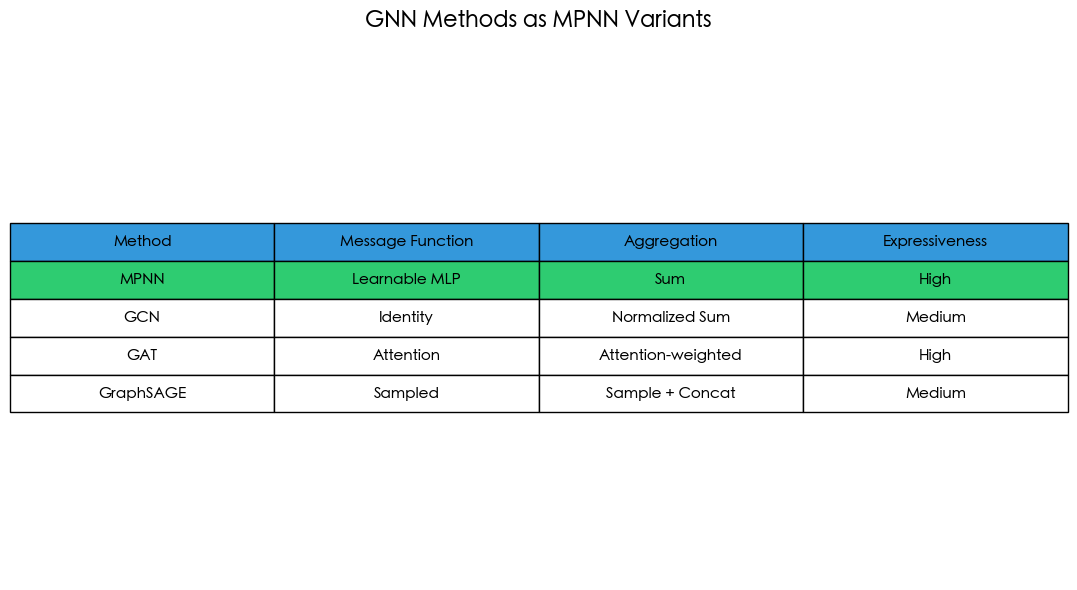

Saved: gnn_comparison.png


In [13]:
# 建立總結比較圖（標籤用英文避免亂碼）
fig, ax = plt.subplots(figsize=(12, 6))

methods = ['MPNN', 'GCN', 'GAT', 'GraphSAGE']
message_fn = ['Learnable MLP', 'Identity', 'Attention', 'Sampled']
aggregation = ['Sum', 'Normalized Sum', 'Attention-weighted', 'Sample + Concat']
expressiveness = ['High', 'Medium', 'High', 'Medium']

cell_text = [[methods[i], message_fn[i], aggregation[i], expressiveness[i]] 
             for i in range(len(methods))]

table = ax.table(
    cellText=cell_text,
    colLabels=['Method', 'Message Function', 'Aggregation', 'Expressiveness'],
    cellLoc='center',
    loc='center',
    colColours=['#3498db']*4
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.5, 2)

# 高亮 MPNN 行
for j in range(4):
    table[(1, j)].set_facecolor('#2ecc71')
    table[(1, j)].set_text_props(weight='bold')

ax.axis('off')
ax.set_title('GNN Methods as MPNN Variants', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('gnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gnn_comparison.png")

In [14]:
print("=" * 60)
print("第十二章：訊息傳遞神經網路 - 完成！")
print("=" * 60)
print("\n重點整理：")
print("1. MPNN 將各種 GNN 方法統一為一個框架")
print("2. 訊息傳遞：從鄰居收集資訊")
print("3. 聚合：結合訊息（求和、平均、最大、注意力）")
print("4. 更新：更新節點表示")
print("5. 讀出：聚合為圖級別預測")
print("6. 過度平滑限制深度通常為 2-4 層")
print("\n儲存的圖片：")
print("  1. water_graph.png")
print("  2. message_passing_evolution.png")
print("  3. aggregation_comparison.png")
print("  4. benzene_graph.png")
print("  5. over_smoothing.png")
print("  6. receptive_field_growth.png")
print("  7. gnn_comparison.png")

第十二章：訊息傳遞神經網路 - 完成！

重點整理：
1. MPNN 將各種 GNN 方法統一為一個框架
2. 訊息傳遞：從鄰居收集資訊
3. 聚合：結合訊息（求和、平均、最大、注意力）
4. 更新：更新節點表示
5. 讀出：聚合為圖級別預測
6. 過度平滑限制深度通常為 2-4 層

儲存的圖片：
  1. water_graph.png
  2. message_passing_evolution.png
  3. aggregation_comparison.png
  4. benzene_graph.png
  5. over_smoothing.png
  6. receptive_field_growth.png
  7. gnn_comparison.png
